# Custom Naive Classifier vs Sklearn Naive Classifier

First we will implement our own custom implementation of Naive Classifier and will compare it with Sklearn Naive Classifier and generate reports.

             Custom Model                                Sklearn Model  \
                precision    recall  f1-score    support     precision   
0                0.851852  0.821429  0.836364  28.000000      0.913043   
1                0.886364  0.906977  0.896552  43.000000      0.854167   
accuracy         0.873239  0.873239  0.873239   0.873239      0.873239   
macro avg        0.869108  0.864203  0.866458  71.000000      0.883605   
weighted avg     0.872753  0.873239  0.872816  71.000000      0.877386   

                                             
                recall  f1-score    support  
0             0.750000  0.823529  28.000000  
1             0.953488  0.901099  43.000000  
accuracy      0.873239  0.873239   0.873239  
macro avg     0.851744  0.862314  71.000000  
weighted avg  0.873239  0.870508  71.000000  


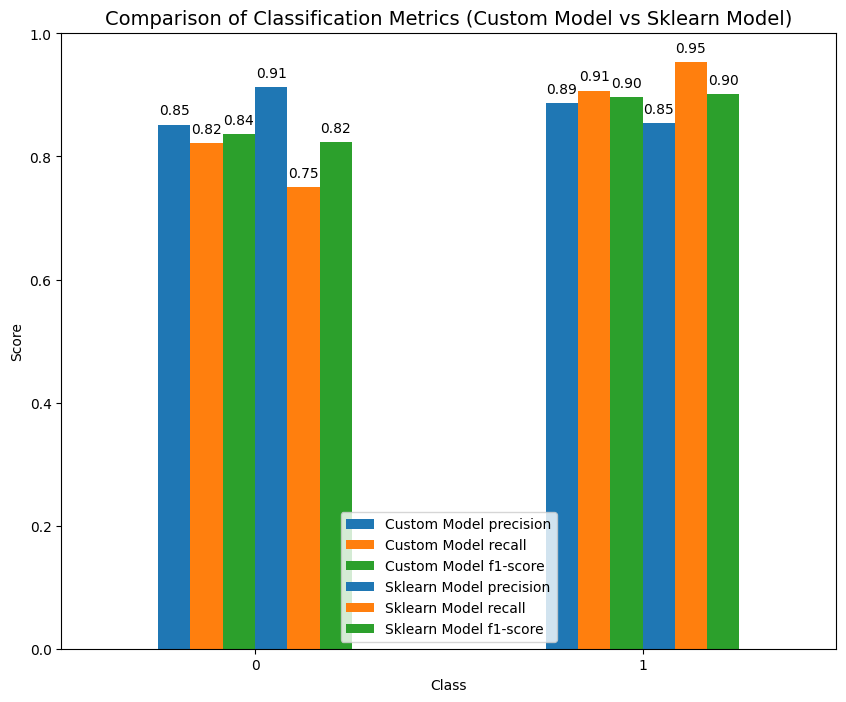

<Figure size 600x700 with 0 Axes>

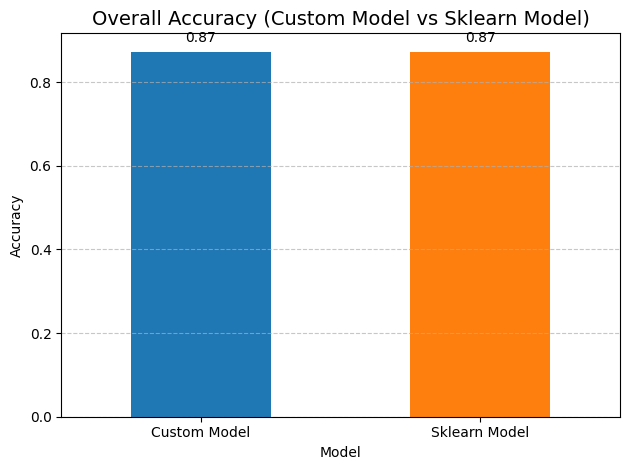

In [37]:
from time import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

# Custom Gaussian Naive Bayes implementation
class CustomGaussianNB:
    def __init__(self):
        self.means = None
        self.variances = None
        self.priors = None
        self.classes = None
        self.epsilon = 1e-6

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.classes = np.unique(y)
        n_classes = len(self.classes)

        self.means = np.zeros((n_classes, n_features), dtype=np.float64)
        self.variances = np.zeros((n_classes, n_features), dtype=np.float64)
        self.priors = np.zeros(n_classes, dtype=np.float64)
        
        for idx, c in enumerate(self.classes):
            X_c = X[y == c]
            self.means[idx, :] = X_c.mean(axis=0)
            self.variances[idx, :] = X_c.var(axis=0) + self.epsilon
            self.priors[idx] = X_c.shape[0] / float(n_samples)

    def _gaussian_density(self, class_idx, x):
        mean = self.means[class_idx]
        var = self.variances[class_idx]
        exponent = - (x - mean) ** 2 / (2 * var)
        numerator = np.exp(exponent)
        numerator = np.where(numerator == 0, self.epsilon, numerator)
        denominator = np.sqrt(2 * np.pi * var)
        return numerator / denominator

    def _log_likelihood(self, X):
        log_likelihoods = []
        for idx, c in enumerate(self.classes):
            prior = np.log(self.priors[idx])
            likelihood = np.sum(np.log(self._gaussian_density(idx, X)), axis=1)
            log_likelihoods.append(prior + likelihood)
        return np.array(log_likelihoods).T

    def predict(self, X):
        log_likelihoods = self._log_likelihood(X)
        return self.classes[np.argmax(log_likelihoods, axis=1)]

    def predict_proba(self, X):
        log_likelihoods = self._log_likelihood(X)
        prob = np.exp(log_likelihoods - np.max(log_likelihoods, axis=1, keepdims=True))
        return prob / np.sum(prob, axis=1, keepdims=True)

# Load data set here and doing required changes like converting good to `1` and bad to `0` and removing `Unnamed: 0` and updated values to numeric
data = pd.read_csv("./ion_binary_classification.csv")
data = data.drop(columns=["Unnamed: 0"])
data["Class"] = data["Class"].map({"good": 1, "bad": 0})
data.iloc[:, :-1] = data.iloc[:, :-1].apply(pd.to_numeric, errors="coerce")

# Split data into train and test
X = data.drop(columns=["Class"])
Y = data["Class"]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Custom Naive Bayes
custom_nb = CustomGaussianNB()
start_time_custom = time()
custom_nb.fit(X_train.values, Y_train.values)
y_pred_custom = custom_nb.predict(X_test.values)
end_time_custom = time()
custom_train_time = end_time_custom - start_time_custom

# Sklearn Naive Bayes
sklearn_nb = GaussianNB()
start_time_sklearn = time()
sklearn_nb.fit(X_train, Y_train)
y_pred_sklearn = sklearn_nb.predict(X_test)
end_time_sklearn = time()
sklearn_train_time = end_time_sklearn - start_time_sklearn

# Metrics for Custom Model
metrics_custom = classification_report(Y_test, y_pred_custom, output_dict=True)
roc_auc_custom = roc_auc_score(Y_test, y_pred_custom)
confusion_matrix_custom = confusion_matrix(Y_test, y_pred_custom)

# Metrics for Sklearn Model
metrics_sklearn = classification_report(Y_test, y_pred_sklearn, output_dict=True)
roc_auc_sklearn = roc_auc_score(Y_test, y_pred_sklearn)
confusion_matrix_sklearn = confusion_matrix(Y_test, y_pred_sklearn)

# Convert the reports into DataFrames
df_report_1 = pd.DataFrame(metrics_custom).transpose()
df_report_2 = pd.DataFrame(metrics_sklearn).transpose()

# Concatenate the two DataFrames side by side
df_combined = pd.concat(
    [df_report_1, df_report_2], axis=1, keys=["Custom Model", "Sklearn Model"]
)

# Check the structure of df_combined
print(df_combined)

# Drop 'support' since it's not needed for the plot
df_metrics = df_combined.drop(
    columns=[("Custom Model", "support"), ("Sklearn Model", "support")]
)

# Flatten the MultiIndex for easier plotting
df_metrics.columns = [
    "Custom Model " + col for col in ["precision", "recall", "f1-score"]
] + ["Sklearn Model " + col for col in ["precision", "recall", "f1-score"]]

# Select rows that contain the actual metrics, not 'accuracy', 'macro avg', etc.
df_filtered = df_metrics.loc[
    ["0", "1"]
]  # Or ['0', '1'] for binary class classification

# Extract overall accuracy for both models
custom_accuracy = df_combined.loc["accuracy", ("Custom Model", "precision")]
sklearn_accuracy = df_combined.loc["accuracy", ("Sklearn Model", "precision")]

# Create a separate DataFrame for accuracy
df_accuracy = pd.DataFrame(
    {
        "Model": ["Custom Model", "Sklearn Model"],
        "Accuracy": [custom_accuracy, sklearn_accuracy],
    }
)

# Plot class-wise metrics (precision, recall, f1-score)
ax = df_filtered.plot(
    kind="bar", figsize=(10, 8), color=["#1f77b4", "#ff7f0e", "#2ca02c"]
)

# Add title and labels
plt.title(
    "Comparison of Classification Metrics (Custom Model vs Sklearn Model)", fontsize=14
)
plt.ylabel("Score")
plt.xlabel("Class")
plt.xticks(rotation=0)

# Add value labels on the class-wise bars
for p in ax.patches:
    ax.annotate(
        format(p.get_height(), ".2f"),
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 10),
        textcoords="offset points",
    )

# Plot overall accuracy as a separate bar graph
plt.figure(figsize=(6, 7))
ax2 = df_accuracy.plot(
    kind="bar", x="Model", y="Accuracy", legend=False, color=["#1f77b4", "#ff7f0e"]
)

# Add title and labels for accuracy
plt.title("Overall Accuracy (Custom Model vs Sklearn Model)", fontsize=14)
plt.ylabel("Accuracy")
plt.xticks(rotation=0)

# Add value labels on the accuracy bars
for p in ax2.patches:
    ax2.annotate(
        format(p.get_height(), ".2f"),
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 10),
        textcoords="offset points",
    )

plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show the plots
plt.tight_layout()
plt.show()